# <span style="color:red"> Lecture 11: More about Functions </span>

<font size="5"> 

In the previous class we:
- Wrote our own custom functions with `def` and `return`
- Learned about **local** vs. **global** variables


<font size="5"> 

In this class we will:

- Write one-line **lambda functions**
- Apply a function to a whole DataFrame column with **`.apply()`**
- Write functions with **no output** - like reusable plotting functions


In [2]:
# for convenience, put all import statements here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

## <span style="color:red"> I. Lambda Functions </span>

<font size = "4">

"Lambda Functions" are defined in one line:

```python
my_function = lambda parameters: expression
```

<font size = "4">

**Example**: Calculate $x + y + z$

In [1]:
# First, we'll do it the "standard way". Two different versions

def sum_xyz(x, y, z):
    out = x + y + z
    return out 

def sum_xyz_v2(x, y, z):
    return x + y + z

# run the functions
my_var = sum_xyz(5, 3, 12)
print(my_var)
print(sum_xyz(5, 3, 12))
print(sum_xyz_v2(5, 3, 12))

20
20
20


In [3]:
# using "lambda" keyword, define a function in one line
fn_sum = lambda x,y,z: x + y + z

# run the function
my_sum = fn_sum(5, 3, 12)
print(my_sum)

20


In [4]:
print(fn_sum(x = 5, y = 3, z = 12))

20


<font size = "4">

Lambda function with two output arguments. This will compute (a) $x + y + z$ and (b) $y - z$

In [5]:
# must include parentheses!
fn_sum_minus = lambda x, y, z: (x + y + z, y - z)

out1, out2 = fn_sum_minus(5, 3, 12)
print(out1)
print(out2)

20
-9


<font size = "5">

A lambda function can also return a **Boolean**. The selection rule from the lab partner problem fits in one line:

In [6]:
# "does this skill beat the benchmark?" as a one-line function
fn_beats = lambda skill, benchmark: skill > benchmark

print(fn_beats(7.94, 6.72))   # Casey vs. a benchmark of 6.72
print(fn_beats(1.51, 6.72))   # Britta vs. the same benchmark

True
False


## <span style="color:red"> II. Pandas .apply() </span>

<font size = "4">

`.apply()` runs a function on **every entry of a DataFrame column**, one at a time.


In [7]:
import pandas as pd

carfeatures = pd.read_csv("data/features.csv")

car_mpg = carfeatures['mpg']

# can we convert miles per gallon into kilometers per liter?

# 1 mile = 1.609344 kilometers
# 1 gallon = 3.785411784 liters

# 18 miles per gallon = 18 * 1.609344 / 3.785411784 kilometers per liter

print("Car 0 mileage (miles per gallon):", car_mpg[0])
print("Car 0 mileage (kilometers per liter):", car_mpg[0]*1.609344/3.785411784)

Car 0 mileage (miles per gallon): 18.0
Car 0 mileage (kilometers per liter): 7.652586733744897


In [8]:
# create a function

def convert_mpg_to_kmpL(mpg_val):
    return mpg_val*1.609344/3.785411784

car_kmpL = car_mpg.apply(convert_mpg_to_kmpL)

# rename heading
car_kmpL.name = "km per liter"

In [9]:
# or use a Lambda function:
fn_convert = lambda mpg: mpg*1.609344/3.785411784

car_kmpL = car_mpg.apply(fn_convert)

# rename heading
car_kmpL.name = "km per liter"

In [10]:
# Use Lambda function that also rounds to 2 decimal places
fn_convert_2digits = lambda mpg: round(mpg*1.609344/3.785411784, 2)

car_kmpL = car_mpg.apply(fn_convert_2digits)

# rename heading
car_kmpL.name = "km per liter"

In [11]:
# Name of inputs DON'T MATTER

fn_convert_to_kmL = lambda my_dumb_variable_name: my_dumb_variable_name*1.609344/3.785411784

car_kmpL = car_mpg.apply(fn_convert_to_kmL)

# rename heading
car_kmpL.name = "km per liter"

<font size = "5">

One more example: let's use `.apply()` with a function that returns a Boolean value

In [12]:
def check_low_mileage(mpg):
    if mpg < 20:
        return True
    else:
        return False

car_lo_mileage = car_mpg.apply(check_low_mileage)
car_lo_mileage.name = "Low mileage"

In [15]:
# The previous function can be condensed. How?

def check_low_mileage(mpg):
    return mpg < 20

car_lo_mileage = car_mpg.apply(check_low_mileage)
car_lo_mileage.name = "Low mileage"

In [ ]:
# Now we'll do it with a lambda function
check_low_mileage = lambda mpg: mpg < 20

car_lo_mileage = car_mpg.apply(check_low_mileage)
car_lo_mileage.name = "Low mileage" 

True

## <span style="color:red"> III. Functions with no output </span>

<font size = "4">

We already saw functions with no output: `print`, and `random.shuffle` (which mutates its list and returns nothing). There are other cases where a useful function can be created without any return values.

A great example: a **plotting function**.

In [13]:
# Define a function which creates a labeled bar plot
import matplotlib.pyplot as plt

def labeled_bar_plot(x_vals, heights, xlabel, ylabel, title):
    plt.bar(x = x_vals, height = heights)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

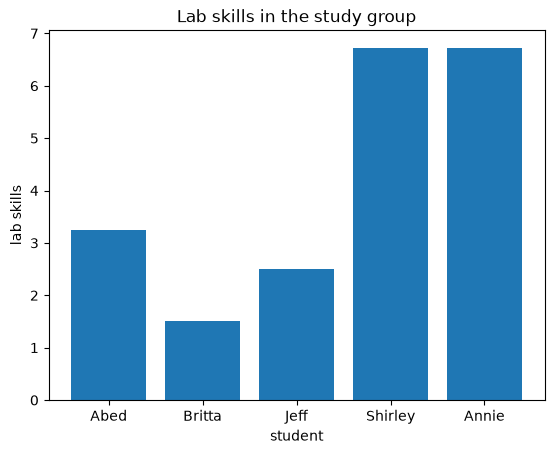

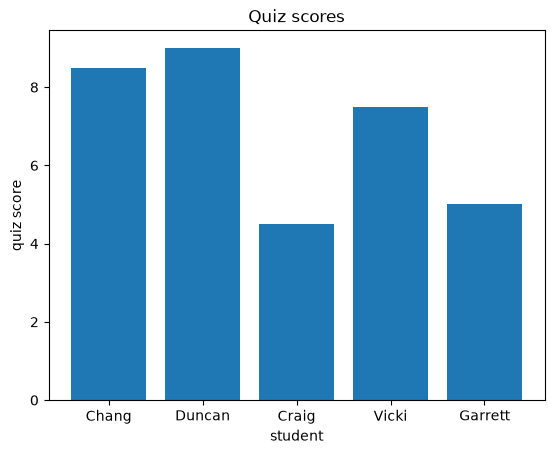

In [14]:
# no assignment to a variable necessary

# our 5-person study group from Lecture 9 (Jeff after his lab safety workshop)
study_names = ["Abed", "Britta", "Jeff", "Shirley", "Annie"]
study_skills = [3.24, 1.51, 2.51, 6.72, 6.72]

labeled_bar_plot(x_vals = study_names, heights = study_skills,
    xlabel = "student", ylabel = "lab skills", title = "Lab skills in the study group")

# call the function again to generate a 2nd plot

# the quiz scores from Lecture 9 (Chang after his 2 extra points)
quiz_names = ["Chang", "Duncan", "Craig", "Vicki", "Garrett"]
quiz_points = [8.5, 9.0, 4.5, 7.5, 5.0]

labeled_bar_plot(x_vals = quiz_names, heights = quiz_points,
    xlabel = "student", ylabel = "quiz score", title = "Quiz scores")

<font size = "4">

- There is no `return` statement, so there is nothing to assign - *calling* the function does its whole job.

- We will reuse `labeled_bar_plot` in the exercises below.

## <span style="color:red"> IV. Changing the input </span>

<font size = "4">

Unlike mathematical functions, functions can change the input too! 

In [18]:
def change_last_element(lst):
    lst[-1] = "Removed"

x = [1, 2, 3]
print(x)
change_last_element(x)
print(x)

[1, 2, 3]
[1, 2, 'Removed']


In [19]:
def zero_last_element(lst):
    lst[-1] = 0.0

x = np.array([1, 2, 3])
print(x)
zero_last_element(x)
print(x)

[1 2 3]
[1 2 0]


In [20]:
def add_element(lst):
    lst.append("New!")

x = [1, 2, 3]
print(x)
add_element(x)
print(x)


[1, 2, 3]
[1, 2, 3, 'New!']


<font size = "4">

However, check out the following:

In [21]:
def add_element(lst):
    lst.append("New!")

def add_element2(lst):
    lst = lst + ["New!"]

x = [1, 2, 3]
print(x)
add_element(x)
print(x)
print()

y = [1, 2, 3]
print(y)
add_element2(y)
print(y)

[1, 2, 3]
[1, 2, 3, 'New!']

[1, 2, 3]
[1, 2, 3]


## <span style="color:red"> Exercises </span>

<font size = "4">

**1.** Using the `lambda` keyword, define a function calculating

$$V=P\left(1+{\frac {r}{n}}\right)^{nt}$$

for arguments $P$, $r$, $n$, and $t$. Check that it gives the same answers as your custom function the Lecture 10 exercises

In [23]:
# your code here

compound_interest = lambda P, r, n, t: P*(1 + r/n)**(n*t)

print(compound_interest(1000, 0.03, 1, 10))

1343.9163793441223


<font size = "4">

**2.** Using the `lambda` keyword, define a function that calculates

$$f(x,y) = y + x^2 + 2x + 1$$

and evaluate it at a couple of points of your choice.

In [25]:
# your code here

math_func = lambda x, y: y + x**2 + 2*x + 1

print(math_func(1, 3))




7


<font size = "4">

**3.** Using the `lambda` keyword, define a function that returns a tuple with two elements:

- Element 0 is the value of $f(x,y) = y + x^2 + 2x + 1$
- Element 1 is the value of the gradient $$\nabla f(x,y) = \begin{bmatrix} \frac{\partial f}{\partial x}(x,y) \\[4pt] \frac{\partial f}{\partial y}(x,y) \end{bmatrix} = \begin{bmatrix} 2x + 2 \\[4pt] 1 \end{bmatrix}$$

In [30]:
math_func = lambda x, y: (y + x**2 + 2*x + 1, np.array([2*x + 2, 1]))

print(math_func(1, 3))


(7, array([4, 1]))


<font size = "4">

**4.** The cell below creates a small DataFrame of numeric grades.

- Write a function with a single parameter `numeric_grade`. Inside the function, write an `if`/`else` statement for `numeric_grade` $\ge 55$: if it's true, return the string `"status = pass"`; otherwise return `"status = fail"`.
- Use `.apply()` to run your function on the `numeric_grade` column, and `display` the result.

In [32]:
df_grades = pd.DataFrame({"name": ["Chang", "Duncan", "Craig", "Vicki", "Garrett"],
                          "numeric_grade": [85, 90, 45, 75, 50]})

# your code here
def pass_fail(numeric_grade):
    status = "status = fail"

    if numeric_grade >= 55:
        status = "status = pass"

    return status

display(df_grades["numeric_grade"].apply(pass_fail))




0    status = pass
1    status = pass
2    status = fail
3    status = pass
4    status = fail
Name: numeric_grade, dtype: str